In [7]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. IMPORT YOUR MODEL CLASSES HERE
from ACOPF_pinn_baseline import baselineQCQPMLP
from ACOPF_pinn_rahul import RahulSinglePINN_Smax

# Helper for quadratic forms
def quad_batch_stack(v: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
    return torch.einsum("bi,kij,bj->bk", v, M, v)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

Executing on: cpu


In [8]:
data = np.load("result/ipopt_baseline_pglib_opf_case14_ieee_1000_instances.npz")
print(data.files) # This will print the keys

['v_optimal', 'pg_optimal', 'qg_optimal', 'status', 'obj_val', 'solve_time']


In [9]:
case_name = 'pglib_opf_case14_ieee'
total_samples = 10000
dataset_path = f'./dataset/{case_name}_{total_samples}.pt'

# Load problem dictionary
problem = torch.load(dataset_path, map_location=device)

# Calculate slice indices
actual_total_samples = problem["Pd_all"].shape[0] 
train_size = int(0.8 * actual_total_samples)
val_size = int(0.1 * actual_total_samples)
test_start = train_size + val_size

# Extract Test Set Load Profiles
test_Pd = problem["Pd_all"][test_start:].to(device)
test_Qd = problem["Qd_all"][test_start:].to(device)

# Load IPOPT Ground Truth
# Adjust the filename if you used a different eval_limit when generating the baseline
gt_path = f'./result/ipopt_baseline_{case_name}_{actual_total_samples - test_start}_instances.npz'
gt_data = np.load(gt_path)

# Extract ground truth variables
test_v_gt = torch.tensor(gt_data['v_optimal'], dtype=torch.float32).to(device)
test_pg_gt = torch.tensor(gt_data['pg_optimal'], dtype=torch.float32).to(device)
test_qg_gt = torch.tensor(gt_data['qg_optimal'], dtype=torch.float32).to(device)

assert test_Pd.shape[0] == test_v_gt.shape[0], "Dataset size mismatch between PINN test set and IPOPT baseline!"

# Deploy matrices to device
for key, value in problem.items():
    if isinstance(value, torch.Tensor):
        problem[key] = value.to(device)

# Build DataLoader
batch_size = 1024 
test_dataset = TensorDataset(test_Pd, test_Qd, test_v_gt, test_pg_gt, test_qg_gt)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Test dataset ready with {len(test_dataset)} samples.")

Test dataset ready with 1000 samples.


In [10]:
def evaluate_model(model: nn.Module, model_name: str, test_loader: DataLoader, problem: dict, device: torch.device):
    model.eval()
    
    total_samples = 0
    total_time = 0.0
    
    all_objs = []
    all_max_eq, all_mean_eq = [], []
    all_max_ineq, all_mean_ineq = [], []
    
    all_mae_v, all_mae_pg, all_mae_qg = [], [], []
    
    # Pre-extract bounds
    smax, angmax, angmin = problem["smax"].unsqueeze(0), problem["angmax"].unsqueeze(0), problem["angmin"].unsqueeze(0)
    Vmin, Vmax = problem["Vmin"].unsqueeze(0), problem["Vmax"].unsqueeze(0)
    pmax, pmin = problem["pmax"].unsqueeze(0), problem["pmin"].unsqueeze(0)
    qmax, qmin = problem["qmax"].unsqueeze(0), problem["qmin"].unsqueeze(0)
    c2, c1, c0 = problem["c2"].unsqueeze(0), problem["c1"].unsqueeze(0), problem["c0"].unsqueeze(0)
    
    # Store predictions for plotting
    plot_data = {"pg_pred": [], "pg_gt": []}

    with torch.no_grad():
        for Pd_batch, Qd_batch, v_gt, pg_gt, qg_gt in test_loader:
            B = Pd_batch.shape[0]
            total_samples += B
            
            start_time = time.perf_counter()
            if model_name == "Rahul Model":
                outputs = model(Pd_batch, Qd_batch)
                v, pg, qg = outputs[0], outputs[1], outputs[2]
            else:
                v, pg, qg = model(Pd_batch, Qd_batch, problem)
            total_time += (time.perf_counter() - start_time)

            # Store for plots
            plot_data["pg_pred"].append(pg.cpu())
            plot_data["pg_gt"].append(pg_gt.cpu())

            # Distance from Ground Truth (MAE)
            all_mae_v.append(torch.abs(v - v_gt).mean().item())
            all_mae_pg.append(torch.abs(pg - pg_gt).mean().item())
            all_mae_qg.append(torch.abs(qg - qg_gt).mean().item())

            # Objective Value
            cost_per_gen = c2.expand(B,-1) * (pg ** 2) + c1.expand(B,-1) * pg + c0.expand(B,-1)
            all_objs.extend(cost_per_gen.sum(dim=1).cpu().numpy())

            # Quadratic Forms & Constraints
            vp = quad_batch_stack(v, problem["M_p"])
            vq = quad_batch_stack(v, problem["M_q"])
            pf, qf = quad_batch_stack(v, problem["M_pf"]), quad_batch_stack(v, problem["M_qf"])
            pt, qt = quad_batch_stack(v, problem["M_pt"]), quad_batch_stack(v, problem["M_qt"])
            vc, vs, vv = quad_batch_stack(v, problem["M_c"]), quad_batch_stack(v, problem["M_s"]), quad_batch_stack(v, problem["M_v"])

            # Equality
            h_p = (pg @ problem["C_g"].T) - Pd_batch - vp
            h_q = (qg @ problem["C_g"].T) - Qd_batch - vq
            eq_violations = torch.cat([h_p.abs(), h_q.abs()], dim=1)
            all_max_eq.append(eq_violations.max().item())
            all_mean_eq.append(eq_violations.mean().item())

            # Inequality
            ineq_violations = torch.cat([
                F.relu((pf**2 + qf**2) - smax.expand(B,-1)**2), F.relu((pt**2 + qt**2) - smax.expand(B,-1)**2), 
                F.relu(pg - pmax.expand(B,-1)), F.relu(pmin.expand(B,-1) - pg), 
                F.relu(qg - qmax.expand(B,-1)), F.relu(qmin.expand(B,-1) - qg),
                F.relu(torch.tan(angmin.expand(B,-1)) * vc - vs), F.relu(vs - torch.tan(angmax.expand(B,-1)) * vc), 
                F.relu(vv - (Vmax.expand(B,-1)**2)), F.relu((Vmin.expand(B,-1)**2) - vv)
            ], dim=1)
            all_max_ineq.append(ineq_violations.max().item())
            all_mean_ineq.append(ineq_violations.mean().item())

    metrics = {
        "Obj. Value": f"{np.mean(all_objs):.2f}",
        "Mean Eq.": f"{np.mean(all_mean_eq):.4f}",
        "Max Ineq.": f"{max(all_max_ineq):.4f}",
        "MAE v": np.mean(all_mae_v),
        "MAE pg": np.mean(all_mae_pg),
        "MAE qg": np.mean(all_mae_qg),
        "Time (s)": total_time / total_samples
    }
    
    # Concat plot data
    plot_data["pg_pred"] = torch.cat(plot_data["pg_pred"], dim=0).numpy()
    plot_data["pg_gt"] = torch.cat(plot_data["pg_gt"], dim=0).numpy()
    
    return metrics, plot_data

In [11]:
slack_imag_idx = (problem["a_ref"] == 1).nonzero(as_tuple=True)[0].item()
nbus, ngen, nbranch = problem["nbus"], problem["ngen"], problem["nbranch"]

# Map your files to your classes here
models_to_evaluate = {
    "PINN Baseline": {"path": "./model/pinn_model_pglib_opf_case14_ieee_10000epochs.pth", "class": baselineQCQPMLP(nbus, ngen, slack_imag_idx).to(device)},
    "DC3 Model": {"path": "./model/dc3_model_pglib_opf_case14_ieee_10000epochs.pth", "class": baselineQCQPMLP(nbus, ngen, slack_imag_idx).to(device)},
    "FSNet Model": {"path": "./model/fsnet_model_pglib_opf_case14_ieee_10000epochs.pth", "class": baselineQCQPMLP(nbus, ngen, slack_imag_idx).to(device)},
    "Rahul Model": {"path": "./model/rahul_pinn_pglib_opf_case14_ieee_10000epochs.pth", "class": RahulSinglePINN_Smax(nbus, ngen, nbranch).to(device)}
}

results_list = []
plot_artifacts = {}

for model_name, config in models_to_evaluate.items():
    model = config["class"]
    try:
        model.load_state_dict(torch.load(config["path"], map_location=device, weights_only=True))
        metrics, plot_data = evaluate_model(model, model_name, test_loader, problem, device)
        
        metrics["Model"] = model_name
        results_list.append(metrics)
        plot_artifacts[model_name] = plot_data
        
    except Exception as e:
        print(f"Skipping {model_name} due to error: {e}")

# Display as Pandas DataFrame
df_results = pd.DataFrame(results_list)
# Reorder columns for readability
df_results = df_results[["Model", "Obj. Value", "Mean Eq.", "Max Ineq.", "MAE v", "MAE pg", "MAE qg", "Time (s)"]]
display(df_results)

,Model,Obj. Value,Mean Eq.,Max Ineq.,MAE v,MAE pg,MAE qg,Time (s)
0,PINN Baseline,1458.24,0.0314,0.0000,1.191610,0.181142,0.094869,0.000008
1,DC3 Model,1487.75,0.0299,0.0000,1.193625,0.173692,0.091736,0.000006
2,FSNet Model,1455.00,0.0315,0.0000,0.052029,0.181961,0.096192,0.000005
3,Rahul Model,8.33,0.0667,2.9055,0.760129,1.083503,1.095946,0.000005


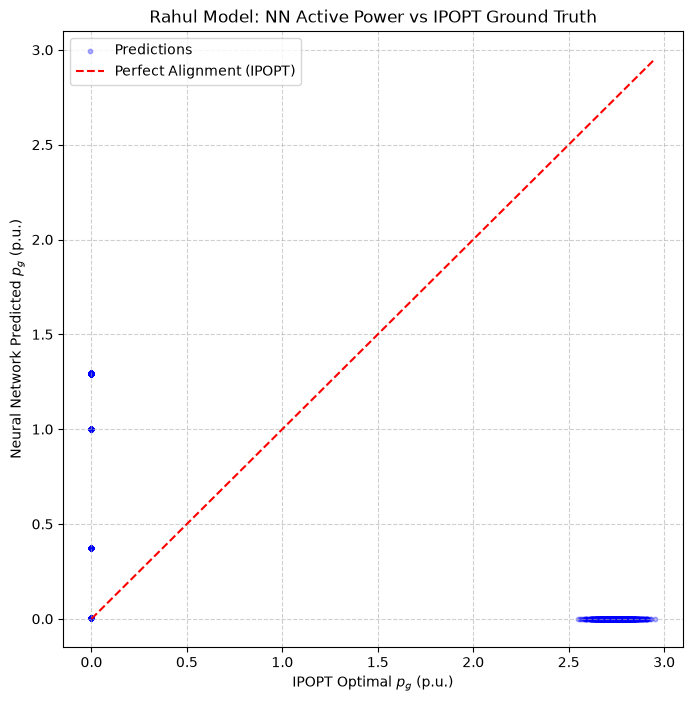

In [12]:
# Choose a model to visualize (e.g., PINN Baseline, DC3 Model, FSNet Model, Rahul Model)
model_to_plot = "Rahul Model"

if model_to_plot in plot_artifacts:
    preds = plot_artifacts[model_to_plot]["pg_pred"].flatten()
    gts = plot_artifacts[model_to_plot]["pg_gt"].flatten()

    plt.figure(figsize=(8, 8))
    plt.scatter(gts, preds, alpha=0.3, s=10, color='blue', label='Predictions')
    
    # Perfect prediction line
    min_val, max_val = min(gts.min(), preds.min()), max(gts.max(), preds.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Alignment (IPOPT)')
    
    plt.title(f"{model_to_plot}: NN Active Power vs IPOPT Ground Truth")
    plt.xlabel("IPOPT Optimal $p_g$ (p.u.)")
    plt.ylabel("Neural Network Predicted $p_g$ (p.u.)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()
else:
    print("Model data not available for plotting.")

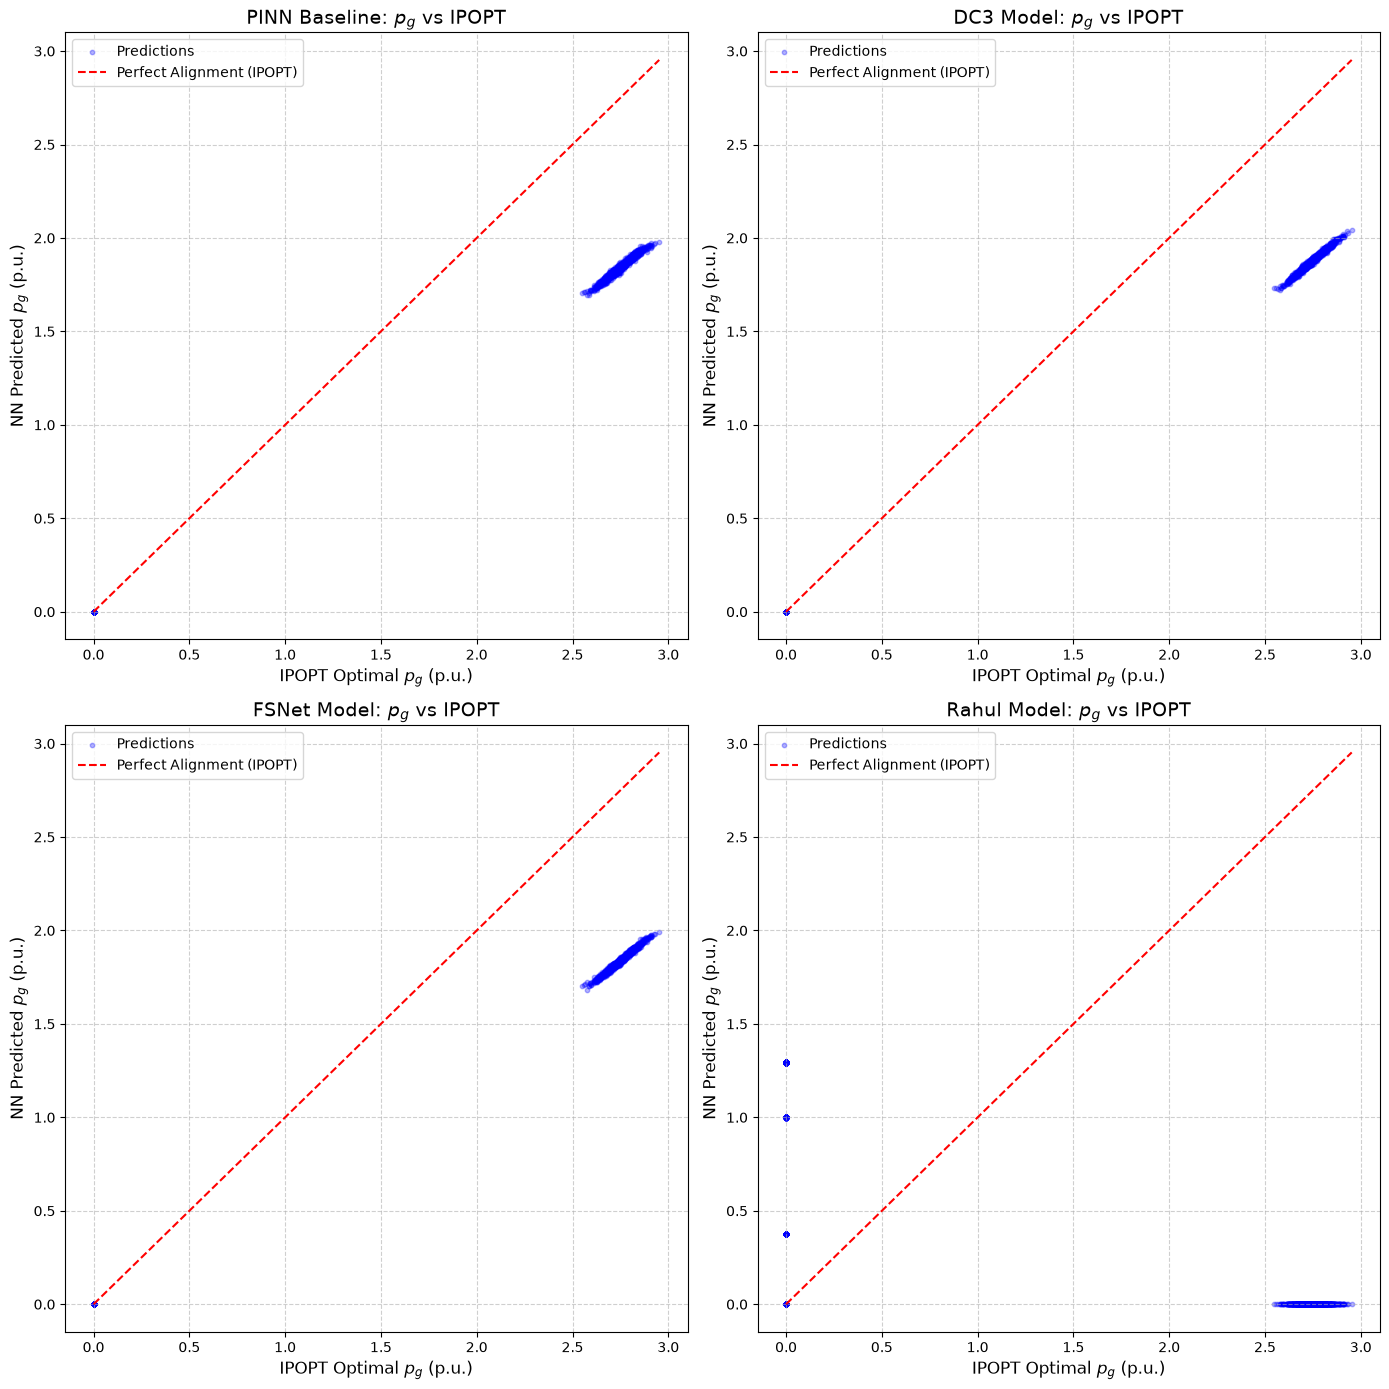

Plot saved successfully to result/active_power_comparison_models.pdf


In [13]:
import matplotlib.pyplot as plt

# List of all the models you want to plot
models_to_plot = ["PINN Baseline", "DC3 Model", "FSNet Model", "Rahul Model"]

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten() # Flatten the 2x2 matrix into a 1D list for easy looping

for i, model_name in enumerate(models_to_plot):
    ax = axes[i] # Get the specific subplot axis
    
    if model_name in plot_artifacts:
        preds = plot_artifacts[model_name]["pg_pred"].flatten()
        gts = plot_artifacts[model_name]["pg_gt"].flatten()

        ax.scatter(gts, preds, alpha=0.3, s=10, color='blue', label='Predictions')
        
        # Perfect prediction line
        min_val, max_val = min(gts.min(), preds.min()), max(gts.max(), preds.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Alignment (IPOPT)')
        
        ax.set_title(f"{model_name}: $p_g$ vs IPOPT", fontsize=14)
        ax.set_xlabel("IPOPT Optimal $p_g$ (p.u.)", fontsize=12)
        ax.set_ylabel("NN Predicted $p_g$ (p.u.)", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
    else:
        # Fallback if a model failed to evaluate and isn't in the dictionary
        ax.text(0.5, 0.5, f"{model_name} data not available", 
                ha='center', va='center', fontsize=12, color='red')
        ax.set_title(model_name)
        ax.axis('off')

# Automatically adjust spacing between subplots so labels don't overlap
plt.tight_layout()

# Save the figure as a PDF (bbox_inches='tight' removes excess white margins)
pdf_filename = "result/active_power_comparison_models.pdf"
plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')

# Display the plot in the notebook
plt.show()

print(f"Plot saved successfully to {pdf_filename}")

# IPOPT

In [1]:
import numpy as np

# Load your baseline file
data = np.load('result/ipopt_baseline_pglib_opf_case14_ieee_1000_instances.npz')

# Extract key arrays
obj_vals = data['obj_val']
solve_times = data['solve_time']

# Filter only successful solves (IPOPT 'optimal' or 'ok')
status = data['status']
mask = np.array(['ok' in s.lower() or 'optimal' in s.lower() for s in status])

valid_objs = obj_vals[mask]
valid_times = solve_times[mask]

# For IPOPT, Eq and Ineq violations are basically 0.0
# We use a very small number to represent solver tolerance (e.g., 1e-7)
print(f"Mean Obj: {np.mean(valid_objs):.2f} ({np.std(valid_objs):.2f})")
print(f"Mean Time: {np.mean(valid_times):.6f} ({np.std(valid_times):.6f})")

Mean Obj: 2175.65 (51.56)
Mean Time: 0.135904 (0.019036)
